In [ ]:
# ===== 패키지 설치 =====
!pip install yfinance scikit-learn tensorflow


In [ ]:

# ===== 라이브러리 로드 =====
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:

# ===== 1. 데이터 수집 =====
df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
close = df[['Close']].copy()


/tmp/ipykernel_15718/2689403149.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:

# ===== 2. 로그수익률 변환 =====
close['log_ret'] = np.log(close['Close'] / close['Close'].shift(1))
close = close.dropna()
log_ret = close[['log_ret']].values


In [ ]:

# ===== 3. 정규화 =====
scaler = MinMaxScaler()
log_ret_scaled = scaler.fit_transform(log_ret)


In [ ]:

# ===== 4. 시퀀스 생성 (window=60) =====
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = create_sequences(log_ret_scaled, window=60)


In [ ]:

# ===== 5. train/test 분리 (80:20) =====
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:

# ===== 6. LSTM 모델 구성 =====
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# ===== 7. 모델 학습 =====
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0402 - val_loss: 0.0055
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0076 - val_loss: 0.0053
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0066 - val_loss: 0.0055
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0063 - val_loss: 0.0055
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0063 - val_loss: 0.0054
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0064 - val_loss: 0.0054
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0062 - val_loss: 0.0054


In [ ]:

# ===== 8. 예측 =====
y_pred_scaled = model.predict(X_test)

# 역정규화
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [ ]:

# ===== 9. 성능 평가 =====
rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred))
mae_lstm  = mean_absolute_error(y_actual, y_pred)
print(f"LSTM RMSE: {rmse_lstm:.6f}")
print(f"LSTM MAE : {mae_lstm:.6f}")


LSTM RMSE: 0.008232
LSTM MAE : 0.006283


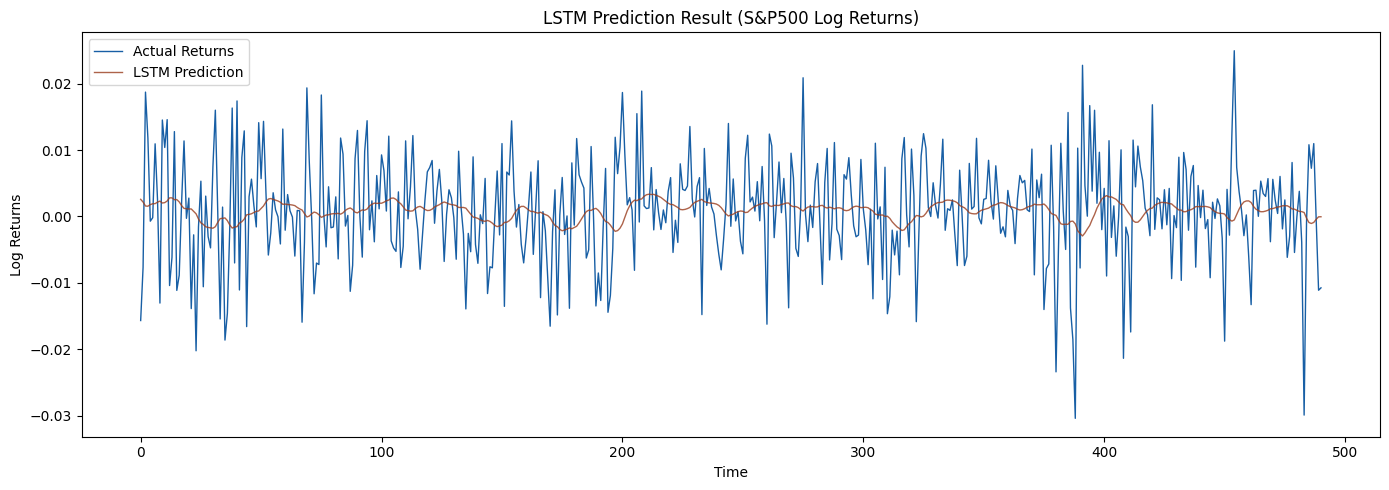

In [ ]:

# ===== 10. 결과 시각화 =====
plt.figure(figsize=(14, 5))
plt.plot(y_actual, label='Actual Returns', color='#185FA5', linewidth=1)
plt.plot(y_pred,   label='LSTM Prediction', color='#993C1D', linewidth=1, alpha=0.8)

plt.title('LSTM Prediction Result (S&P500 Log Returns)')
plt.xlabel('Time')
plt.ylabel('Log Returns')

plt.legend()
plt.tight_layout()
plt.savefig('lstm_result.png', dpi=150)
plt.show()


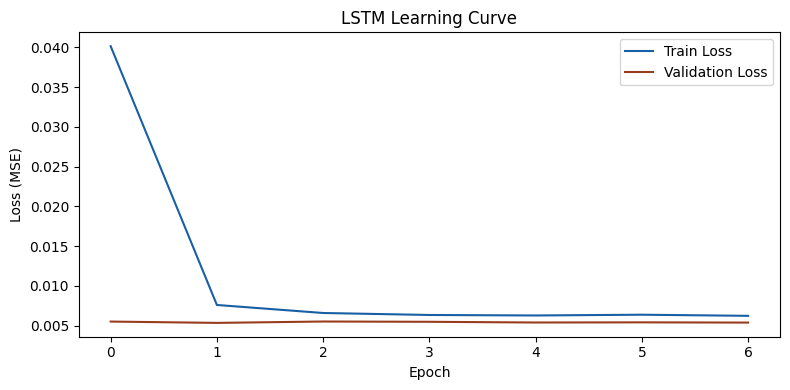

In [ ]:

# ===== 11. 학습 곡선 =====
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'],     label='Train Loss', color='#185FA5')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#993C1D')

plt.title('LSTM Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()

In [ ]:
# ===== 패키지 설치 =====
!pip install neuralforecast yfinance


In [ ]:

# ===== 라이브러리 로드 =====
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:

# ===== 데이터 준비 =====
df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
close = df[['Close']].copy()
close['log_ret'] = np.log(close['Close'] / close['Close'].shift(1))
close = close.dropna().reset_index()


/tmp/ipykernel_35089/3989002038.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:

# NeuralForecast 형식으로 변환 (ds, y, unique_id 필수)
data = pd.DataFrame({
    'unique_id': 'SP500',
    'ds': pd.to_datetime(close['Date']),
    'y': close['log_ret'].values
})

print(data.head())
print(f"데이터 길이: {len(data)}")


  unique_id         ds         y
0     SP500 2015-01-05 -0.018447
1     SP500 2015-01-06 -0.008933
2     SP500 2015-01-07  0.011563
3     SP500 2015-01-08  0.017730
4     SP500 2015-01-09 -0.008439
데이터 길이: 2514


In [ ]:

# ===== train/test 분리 =====
split = int(len(data) * 0.8)
train = data.iloc[:split]
test  = data.iloc[split:]

pred_len = len(test)
print(f"Train: {len(train)}일, Test: {pred_len}일")


Train: 2011일, Test: 503일


In [ ]:

# ===== PatchTST 모델 설정 =====
models = [PatchTST(
    h = pred_len,
    input_size = 336,
    patch_len = 16,
    stride = 8,
    max_steps = 100,
    batch_size = 32,
)]

nf = NeuralForecast(models=models, freq='B')


INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:

# ===== 모델 학습 =====
nf.fit(df=train)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 3.1 M  | train
-----------------------------------------------------------
3.1 M     Trainable params
3         Non-trainable params
3.1 M     Total params
12.439    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


In [ ]:

# ===== 예측 =====
forecast = nf.predict()
print(forecast.head())


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

  unique_id         ds  PatchTST
0     SP500 2022-12-29 -0.000818
1     SP500 2022-12-30 -0.001647
2     SP500 2023-01-02  0.000697
3     SP500 2023-01-03  0.003360
4     SP500 2023-01-04  0.003357


In [ ]:

# ===== 성능 평가 =====
y_pred   = forecast['PatchTST'].values[:len(test)]
y_actual = test['y'].values[:len(y_pred)]

rmse_patch = np.sqrt(mean_squared_error(y_actual, y_pred))
mae_patch  = mean_absolute_error(y_actual, y_pred)
print(f"PatchTST RMSE: {rmse_patch:.6f}")
print(f"PatchTST MAE : {mae_patch:.6f}")


PatchTST RMSE: 0.008565
PatchTST MAE : 0.006608


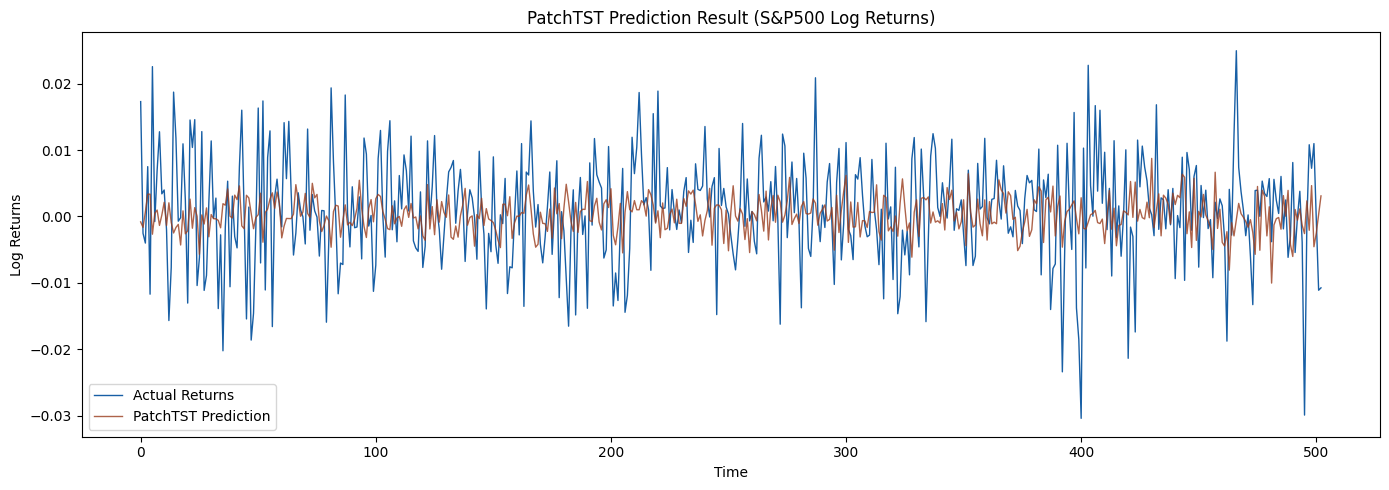

In [ ]:

# ===== 결과 시각화 =====
plt.figure(figsize=(14, 5))

plt.plot(y_actual, label='Actual Returns', color='#185FA5', linewidth=1)
plt.plot(y_pred,   label='PatchTST Prediction', color='#993C1D', linewidth=1, alpha=0.8)

plt.title('PatchTST Prediction Result (S&P500 Log Returns)')
plt.xlabel('Time')
plt.ylabel('Log Returns')

plt.legend()
plt.tight_layout()
plt.savefig('patchtst_result.png', dpi=150)

plt.show()

In [ ]:
# ===== 패키지 설치 =====
!pip install chronos-forecasting yfinance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:

# ===== 라이브러리 로드 =====
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:

# ===== 데이터 준비 =====
df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
close = df[['Close']].copy()
close['log_ret'] = np.log(close['Close'] / close['Close'].shift(1))
close = close.dropna().reset_index()
log_ret = close['log_ret'].values


/tmp/ipykernel_927/1454654848.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:

# ===== train/test 분리 (80:20) =====
split = int(len(log_ret) * 0.8)
train = log_ret[:split]
test  = log_ret[split:]

print(f"Train: {len(train)}일, Test: {len(test)}일")


Train: 2011일, Test: 503일


In [ ]:

# ===== Chronos 모델 로드 =====
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",   # small 버전 (빠름)
    device_map="cpu",            # Colab GPU 없을 때 cpu
    torch_dtype=torch.float32,
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [ ]:

# ===== Zero-shot 예측 =====
context = torch.tensor(train, dtype=torch.float32)

# predict_quantiles 사용
quantiles, mean = pipeline.predict_quantiles(
    inputs=context,
    prediction_length=len(test),
    quantile_levels=[0.1, 0.5, 0.9],
)

# 중앙값 + 10/90 퍼센타일
low    = quantiles[0, :, 0].numpy()  # 10%
median = quantiles[0, :, 1].numpy()  # 50% (중앙값)
high   = quantiles[0, :, 2].numpy()  # 90%



In [ ]:
# ===== 성능 평가 =====
rmse_chronos = np.sqrt(mean_squared_error(test, median))
mae_chronos  = mean_absolute_error(test, median)
print(f"Chronos RMSE: {rmse_chronos:.6f}")
print(f"Chronos MAE : {mae_chronos:.6f}")

Chronos RMSE: 0.008165
Chronos MAE : 0.006220


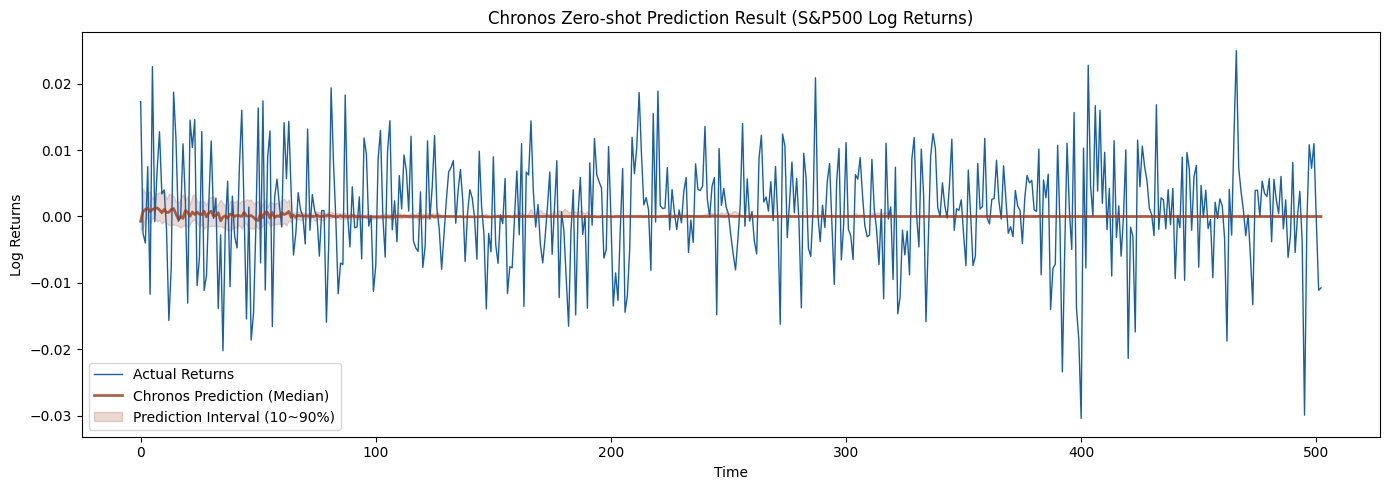

In [ ]:
# ===== 결과 시각화 =====
plt.figure(figsize=(14, 5))
plt.plot(test, label='Actual Returns', color='#185FA5', linewidth=1)
plt.plot(median, label='Chronos Prediction (Median)', color='#993C1D', linewidth=2, alpha=0.8)
plt.fill_between(

    range(len(test)),

    low,

    high,

    alpha=0.2,

    color='#993C1D',

    label='Prediction Interval (10~90%)'

)

plt.title('Chronos Zero-shot Prediction Result (S&P500 Log Returns)')
plt.xlabel('Time')
plt.ylabel('Log Returns')

plt.legend()
plt.tight_layout()
plt.savefig('chronos_result.png', dpi=150)

plt.show()